# DATA 3402 Final Project-Summer 2026

## **Assignment Submission Guidelines**


Please follow the guidelines below for submitting your assignment:

1. **Submission Deadline:**
   - All assignments must be submitted **no later than 11:59 PM the final exam day (08/07) Midnight**.
   - Late submissions will not be accepted.

2. **Submission Platform:**
   - Submit your assignment through **Canvas**.

3. **Required Files:**
   - **Jupyter Notebook file (.ipynb):** Submit the Jupyter Notebook file you used to complete the assignment. The file should contain your well-commented code.
   - **PDF Version (.pdf file):** Additionally, submit a PDF version of your Python code. This can be a printout or export of your script, showing all the code with any necessary explanations or output results included.

4. **File Naming Convention:**
   - Please name your files as follows: `Group Name_AssignmentName`
   - Example: `Group 1_Final_Project.ipynb` and `Group 1_Final_Project.pdf`

5. **Technical Issues:**
   - If you encounter any technical issues with Canvas or your submission, please contact the TAs immediately **before the deadline** to avoid penalties.


## Guideline

Your final project presentations will be held on Tuesday, August 4th, from 1:00 PM to 3:00 PM.

Each group will have approximately 20 minutes to present their project and findings.

**Please confirm and sign up for your group by midnight on July 23rd.**

The dataset list file contains the datasets assigned to each group.
You are not limited to these datasets—if you wish to use a different one, please contact Dr. Ce Brian Bian in advance to confirm its suitability.

This notebook serves as a step-by-step guide to help you complete your final project successfully.

This notebook outlines the steps you should follow. Note that you will be only considering classification projects.

## Data Loading and Initial Look

* Load the data.
* Count the number of rows (data points) and features.
* Any missing values?
* Make a table, where each row is a feature or collection of features:
    * Is the feature categorical or numerical
    * What values?
        * e.g. for categorical: "0,1,2"
        * e.g. for numerical specify the range
    * How many missing values
    * Do you see any outliers?
        * Define outlier.
* For classification is there class imbalance?
* What is the target:
    * Classification: how is the target encoded (e.g. 0 and 1)?
    * Regression: what is the range?

In [223]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
import numpy as np
import pandas as pd

df = pd.read_csv('springleaf-marketing-response/train.csv', low_memory=False)

In [224]:
df = df.sample(10_000)

for c in df.select_dtypes('float64').columns:
    df[c] = df[c].astype('float32')

In [225]:
rows, cols = df.shape
features = [c for c in df.columns if c not in ('ID', 'target')]
num_cols = df[features].select_dtypes(include=[np.number]).columns.tolist()
str_cols = [c for c in features if c not in num_cols]

print('Row and Feature count:')
print(f'Rows: {rows}')
print(f'Columns: {cols}')
print(f'Features: {len(features)}')

Row and Feature count:
Rows: 10000
Columns: 1934
Features: 1932


In [250]:
missing_count = df[features].isna().sum()
missing_pct = missing_count / rows
num_cells = rows * len(features)
print('Missing values:')
print(f'Columns with >= 1 missing: {(missing_count > 0).sum()}')
print(f'Columns >50% missing: {(missing_pct > 0.5).sum()}')
print(f'Columns 100% missing: {(missing_pct == 1.0).sum()}')

Missing values:
Columns with >= 1 missing: 525
Columns >50% missing: 24
Columns 100% missing: 4


In [248]:
def group_size(n):
    if n <= 1:
        return 'constant (useless)'
    if n <= 10:
        return 'few values (2-10)'
    if n <= 20:
        return 'relatively diverse values (11-20)'
    return 'many values (21+)'

n_unique = df[features].nunique()
kind = df[features].dtypes.astype(str).apply(lambda d: 'number' if d.startswith(('int', 'float')) else 'text')
group = n_unique.apply(group_size)

print('Feature Table')
display(pd.crosstab(kind, group, rownames=['type'], colnames=['distinct values']))

print(f'Constant features (no information): {(n_unique <= 1).sum()}')
print(f'Features with 20 or fewer values: {(n_unique <= 20).sum()}')
print(f'Features more than half missing: {(missing_pct > 0.5).sum()}')

Feature Table


distinct values,constant (useless),few values (2-10),many values (21+),relatively diverse values (11-20)
type,,,,
number,61,574,1004,256
text,4,11,22,0


Constant features (no information): 65
Features with 20 or fewer values: 906
Features more than half missing: 24


In [227]:
print('Outliers:')
print('Definition: An outlier is a data point that lies an abnormal distance from other values in a dataset, significantly differing from the overall pattern or distribution.')
print('Looking for outliers in this dataset is complicated. The only kind of outlier we\'re reasonably able to investigate are placeholder variables.')
print('Since our data is anonymized and unitless, separating outliers from legtimiate values is difficult. For the sake of practicality, we made the ')
print('decision to only try to identify and correct placeholder values as outliers.')

Outliers:
Definition: An outlier is a data point that lies an abnormal distance from other values in a dataset, significantly differing from the overall pattern or distribution.
Looking for outliers in this dataset is complicated. The only kind of outlier we're reasonably able to investigate are placeholder variables.
Since our data is anonymized and unitless, separating outliers from legtimiate values is difficult. For the sake of practicality, we made the 
decision to only try to identify and correct placeholder values as outliers.


In [228]:
target_counts = df['target'].value_counts().sort_index()

print('Class Imbalance:')
for value, count in target_counts.items():
    print(f'{value}: {count} ({round(100 * count / rows, 2)}%)')
print(f'Imbalance in the target variable is noticeable but not extreme.')

Class Imbalance:
0: 7757 (77.57%)
1: 2243 (22.43%)
Imbalance in the target variable is noticeable but not extreme.


In [229]:
print('The target and its encoding:')
print('For this project, the target is "target".')
print('dtpe: int64')
print('Values: {0, 1}')
print('Missing: 0')

The target and its encoding:
For this project, the target is "target".
dtpe: int64
Values: {0, 1}
Missing: 0


## Data Visualization

* For classification: compare histogram every feature between the classes. Lots of examples of this in class.
* For regression:
    * Define 2 or more class based on value of the regression target.
        * For example: if regression target is between 0 and 1:
            * 0.0-0.25: Class 1
            * 0.25-0.5: Class 2
            * 0.5-0.75: Class 3
            * 0.75-1.0: Class 4
    * Compare histograms of the features between the classes.
        
* Note that for categorical features, often times the information in the histogram could be better presented in a table.    
* Make comments on what features look most promising for ML task.

Question: What is the imbalance between the classes of the target variable?


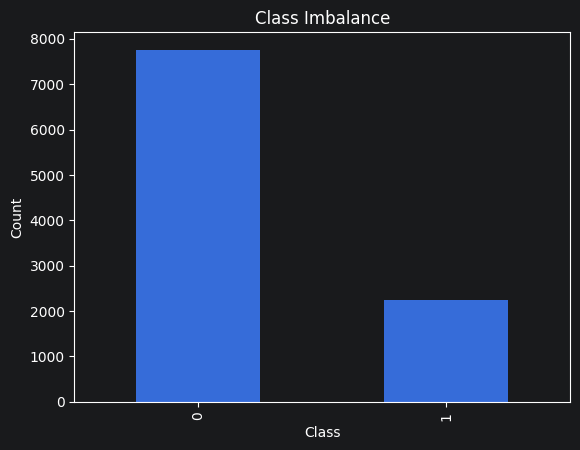

In [230]:
print('Question: What is the imbalance between the classes of the target variable?')
target_counts.plot.bar()
plt.title('Class Imbalance')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

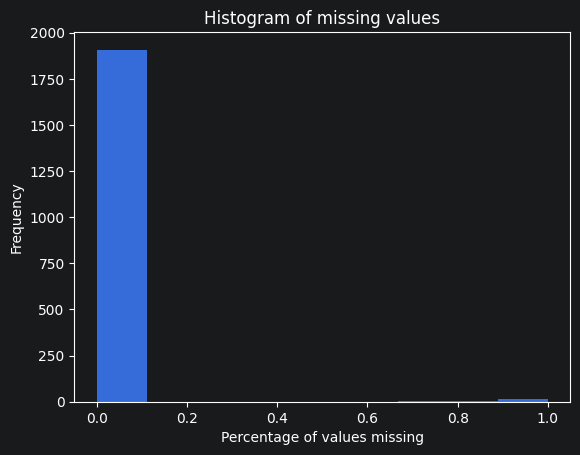

In [231]:
missing_pct.plot.hist(bins=9)
plt.title('Histogram of missing values')
plt.xlabel('Percentage of values missing')
plt.ylabel('Frequency')
plt.show()

Question: Among columns missing more than 1% of values, as a percentage, how many values are they missing?


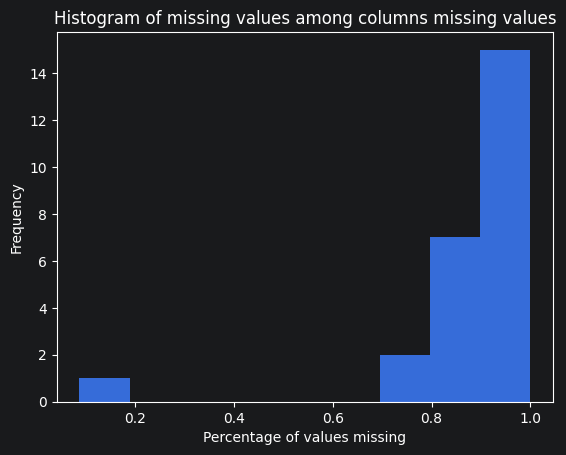

In [232]:
print('Question: Among columns missing more than 1% of values, as a percentage, how many values are they missing?')
missing_pct[missing_pct > 0.01].plot.hist(bins=9)
plt.title('Histogram of missing values among columns missing values')
plt.ylabel('Frequency')
plt.xlabel('Percentage of values missing')
plt.show()

Question: How frequently do the placeholder values occur?


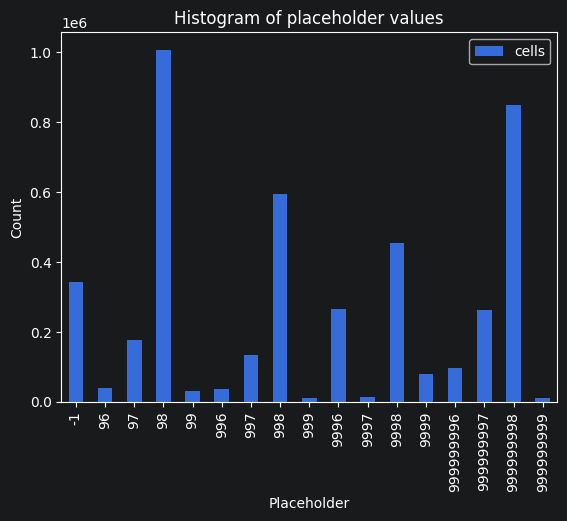

In [233]:
print('Question: How frequently do the placeholder values occur?')
plchldr_table.plot.bar(x='value', y='cells')
plt.xlabel('Placeholder')
plt.ylabel('Count')
plt.title('Histogram of placeholder values')
plt.show()

Question: What features appear to be most promising?


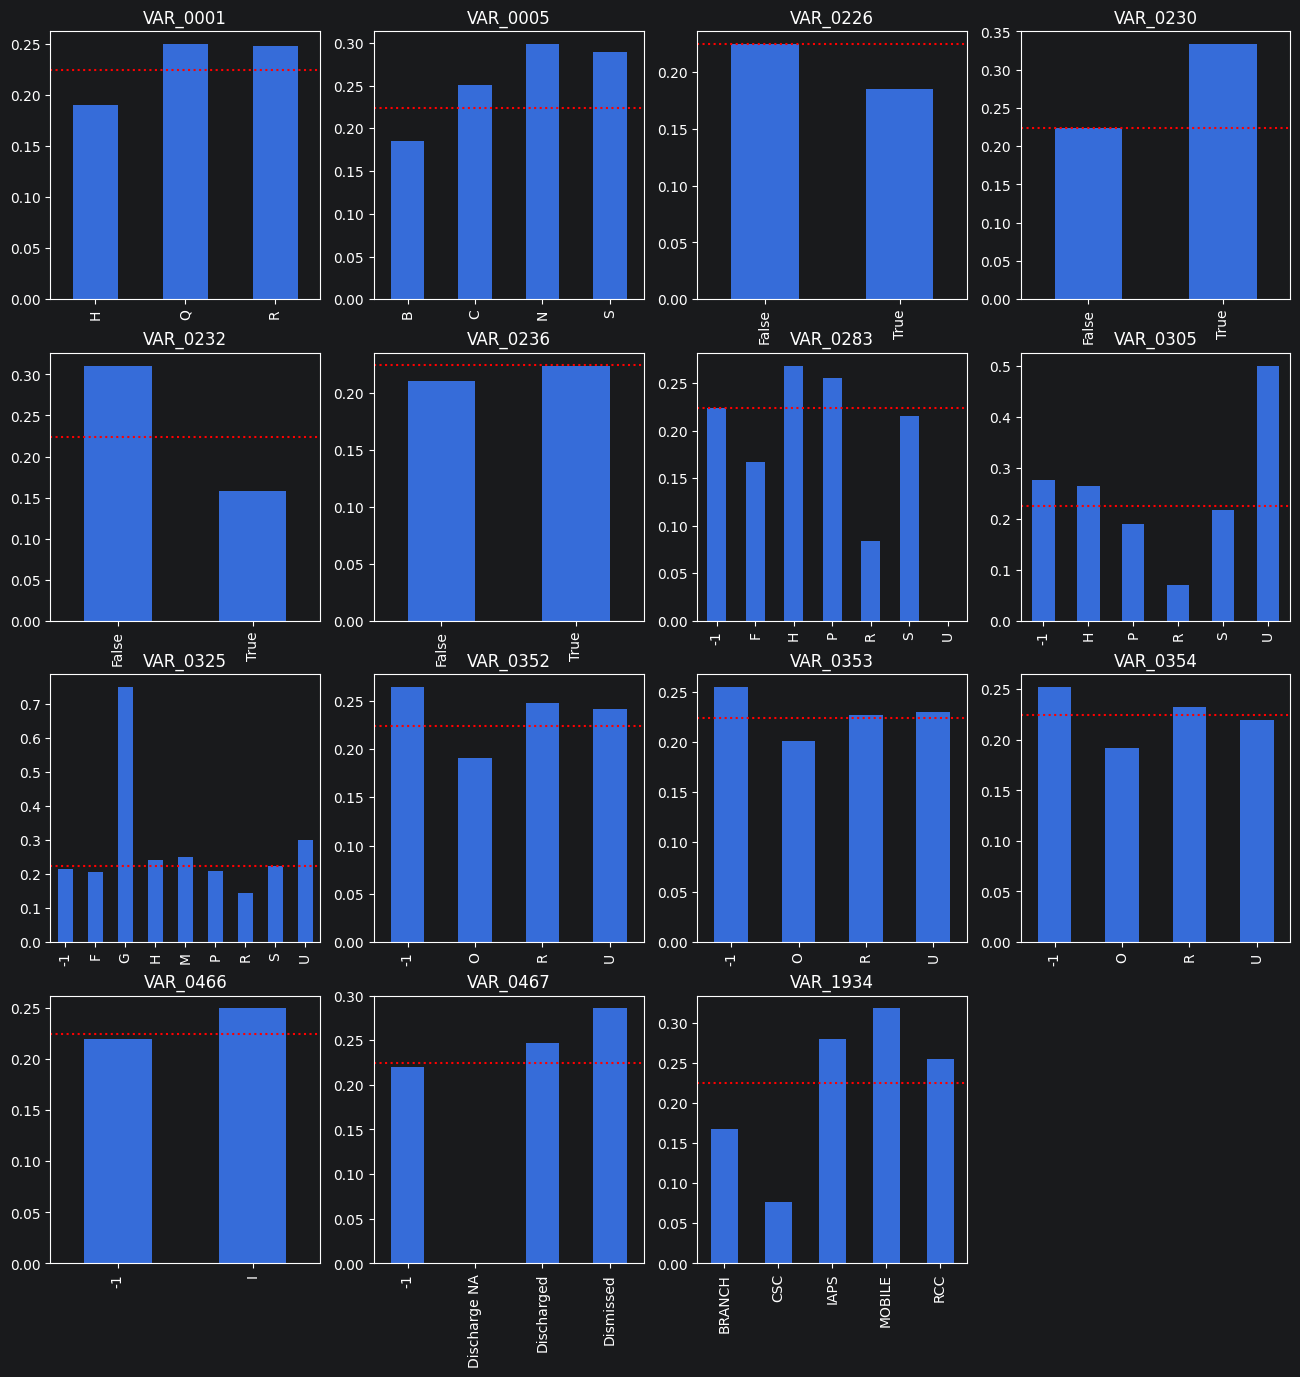

Some of the text features appear to show predictive potential for the target variable
Here, we visualize a set of 16 columns and their categorical predictive power for the target variable.
Ultimately, we won't be filtering to just the most promising ones


In [234]:
print('Question: What features appear to be most promising?')
# Text features with few enough categories to fit on a bar chart.
low_card_text = n_unique[(kind == 'text') & (n_unique >= 2) & (n_unique <= 20)].index

plt.figure(figsize=(16, 16))

for i in range(len(low_card_text)):
    col = low_card_text[i]
    plt.subplot(4, 4, i + 1)
    df.groupby(col)['target'].mean().plot.bar()
    # line is the overall response rate, just a reference to see how predictive it is.
    plt.axhline(df['target'].mean(), color='red', linestyle='dotted')
    plt.title(col)
    plt.xlabel('')

plt.show()

print('Some of the text features appear to show predictive potential for the target variable')
print('Here, we visualize a set of 16 columns and their categorical predictive power for the target variable.')
print('Ultimately, we won\'t be filtering to just the most promising ones')

## Data Cleaning and Preperation for Machine Learning

* Perform any data cleaning. Be clear what are you doing, for what feature.
* Determinine if rescaling is important for your Machine Learning model.
    * If so select strategy for each feature.
    * Apply rescaling.
* Visualize the features before and after cleaning and rescaling.
* One-hot encode your categorical features.

In [241]:
# Converting True and False values to numeric, some cols of Bool type will become constant val columns and will be caught by the drop later.
print(f'An example of a constant valued boolean column: \n {df['VAR_0008'].value_counts()}\n')
df = df.replace({True: 1,False: 0})
# After replacement
print(f'Values after replacement: \n {df['VAR_0008'].value_counts()}\n')

An example of a constant valued boolean column: 
 VAR_0008
0.0    9996
Name: count, dtype: int64

Values after replacement: 
 VAR_0008
0.0    9996
Name: count, dtype: int64



In [242]:
# useless columns containing no real information.
constant_features = n_unique[n_unique <= 1].index
df_clean = df.drop(columns=constant_features)
var_0008 = True

if var_0008 not in list(df_clean.columns):
    var_0008 = False

print(f'Dropped {len(constant_features)} constant columns.')
print(f'Is VAR_0008 still in the dataframe? {var_0008}.')

Dropped 65 constant columns.
Is VAR_0008 still in the dataframe? False.


In [243]:
# drop_duplicates will annihilate original dtypes, saving them.
saved_dtypes = df_clean.dtypes

# Transposing the dataframe to take advantage of the drop_duplicates method.
flipped = df_clean.T
flipped = flipped.drop_duplicates()
df_clean = flipped.T

# Putting the dtypes back.
df_clean = df_clean.astype(saved_dtypes[df_clean.columns])
print(f'Dropped {len(saved_dtypes) - len(df_clean.columns)} duplicate features.')

Dropped 20 duplicate features.


In [244]:
# Dropping columns that are at least almost entirely null, they won't contribute to model performance.
# 250 was chosen arbitrarily.
non_null_min = 250
non_null_df = df_clean.notna().sum()
high_null_cols = non_null_df[non_null_df < non_null_min].index
df_clean = df_clean.drop(columns=high_null_cols)
print(f'Dropped {len(high_null_cols)} columns with fewer than {non_null_min} non-null rows.')

Dropped 6 columns with fewer than 250 non-null rows.


In [245]:
# Working with dates, if a text column can parse as a date then we drop it.
date_format = '%d%b%y:%H:%M:%S'
date_cols = []

for col in df_clean.select_dtypes(exclude=[np.number]).columns: # ignore number columns
    date_test_col = pd.to_datetime(df_clean[col], format=date_format, errors='coerce')
    if date_test_col.notna().sum() > 0:
        # More than one date? You're a date column and we don't want you.
        date_cols.append(col)

df_clean = df_clean.drop(columns=date_cols)
print(f'Dropped {len(date_cols)} date columns.')

# The text columns that are left turn into numbers so the model can read them.
for col in df_clean.select_dtypes(exclude=[np.number]).columns:
    df_clean[col] = df_clean[col].astype('category').cat.codes

print(f'Columns before cleaning: {df.shape[1]}')
print(f'Columns after cleaning: {df_clean.shape[1]}')

Dropped 12 date columns.
Columns before cleaning: 1934
Columns after cleaning: 1831


In [236]:
print('For our choice of ML model, rescaling is not needed. HistGradientBoostingClassifier works well')
print('with unscaled data. We avoided one-hot encoding because this would massively expand the width')
print('of our already impractically wide dataframe.')

For our choice of ML model, rescaling is not needed. HistGradientBoostingClassifier works well
with unscaled data. We avoided one-hot encoding because this would massively expand the width
of our already impractically wide dataframe.


Missing values:
Features with >= 1 missing: 525
Features >50% missing: 24
Features 100% missing: 4

Assumed Placeholders:
We will assume certain values are placeholders for missing values.
The true count of missing values is unknown, and is under-reported by pandas
since pandas assumes these values are valid.


,value,columns,cells,pct_of_cells
0,-1,99,339433,1.76
1,96,361,38438,0.20
2,97,543,175198,0.91
3,98,645,992040,5.13
4,99,804,29199,0.15
5,996,155,35599,0.18
6,997,237,132509,0.69
7,998,282,586474,3.04
8,999,344,9662,0.05
9,9996,102,267681,1.39


Placeholder handling:
Each column is checked against the placeholder list one value at a time.
Replaced 4336979 placeholder values with NaN.


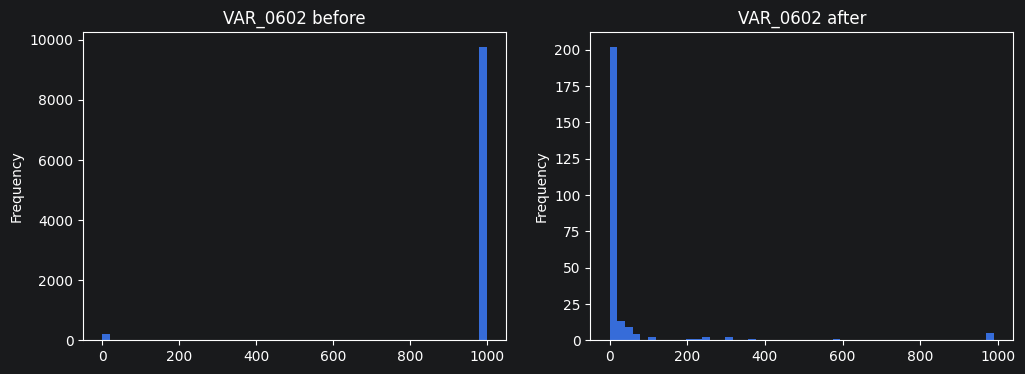

In [237]:
# Please note: This section was originally in the first EDA section, it was moved here so all placeholder related code is in one spot.
assumed_placeholders = [-1, 96, 97, 98, 99, 996, 997, 998, 999, 9996, 9997, 9998, 9999, 999999996, 999999997, 999999998, 999999999]

plchldr_count = pd.Series(0, index=num_cols, dtype='int64')
plchldr_rows = []

for plchldr in assumed_placeholders:
    hit = (df[num_cols] == plchldr).sum()
    plchldr_count = plchldr_count + hit
    if hit.sum() > 0:
        plchldr_rows.append({'value': plchldr,
                              'columns': int((hit > 0).sum()),
                              'cells': int(hit.sum())})

plchldr_table = pd.DataFrame(plchldr_rows)
plchldr_table['pct_of_cells'] = (100 * plchldr_table['cells'] / num_cells).round(2)

# Saving a copy of one column so we can see the before and after.
example_col = 'VAR_0602'
before_values = df_clean[example_col].copy()

numeric_col = df_clean.select_dtypes(include=[np.number]).columns.drop(['ID', 'target'])

replaced_cells = 0

# We will naievely drop all the assumed placeholder values.
for col in numeric_col:
    for placeholder in assumed_placeholders:
        count = (df_clean[col] == placeholder).sum()
        if count > 0:
            df_clean[col] = df_clean[col].replace(placeholder, np.nan)
            replaced_cells += count

print('Placeholder handling:')
print('Each column is checked against the placeholder list one value at a time.')
print(f'Replaced {replaced_cells} placeholder values with NaN.')

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
before_values.plot.hist(bins=50)
plt.title(f'{example_col} before')

plt.subplot(1, 2, 2)
df_clean[example_col].plot.hist(bins=50)
plt.title(f'{example_col} after')

plt.show()

## Machine Learning


### Problem Formulation

* Remove unneed columns, for example:
    * duplicated
    * categorical features that were turned into one-hot.
    * features that identify specific rows, like ID number.
    * make sure your target is properly encoded also.
* Split training sample into train, validation, and test sub-samples.

### Train ML Algorithm

* You only need one algorithm to work. You can do more if you like.
* For now, focus on making it work, rather than best result.
* Try to get a non-trivial result.

### Evaluate Performance on Validation Sample

* Compute the usual metric for your ML task.
* Compute the score for the kaggle challenge.

### Apply ML to the challenge test set

* Once trained, apply the ML algorithm the the test dataset and generate the submission file.


In [238]:
X = df_clean.drop(columns=['ID', 'target'])
y = df_clean['target']

# We used a more "manual" version of this in class, but I prefer this method.
X_train, X_rest, y_train, y_rest = train_test_split(X, y, test_size=0.4, random_state=0, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, test_size=0.5, random_state=0, stratify=y_rest)

print('Splitting into train, validation, and test (60/20/20):')
print(f'train: {len(X_train)} rows.')
print(f'validation: {len(X_val)} rows.')
print(f'test: {len(X_test)} rows.')

Splitting into train, validation, and test (60/20/20):
train: 6000 rows.
validation: 2000 rows.
test: 2000 rows.


In [239]:
model = HistGradientBoostingClassifier(max_iter=500, learning_rate=0.05, early_stopping=True, validation_fraction=0.1, random_state=0)
model.fit(X_train, y_train)

print('HistGradientBoostingClassifier was chosen for four reasons:')
print('I (Christian) happened to randomly choose it for lab 8, so I\'m a little familiar with it.')
print('It handles NaN without issue, so missing data doesn\'t need imputing, no rescaling, since ')
print('its tree-based, and apparently its well-suited for very wide data.')
print(f'Training stopped after {model.n_iter_} of {model.max_iter} iterations.')

HistGradientBoostingClassifier was chosen for four reasons:
I (Christian) happened to randomly choose it for lab 8, so I'm a little familiar with it.
It handles NaN without issue, so missing data doesn't need imputing, no rescaling, since 
its tree-based, and apparently its well-suited for very wide data.
Training stopped after 86 of 500 iterations.


Evaluation on the validation set:
Kaggle scored this problem on AUC, which is why we selected it here.

Validation AUC: 0.7347
Test AUC: 0.7452
Very close AUC, I don' think it's overfitting.


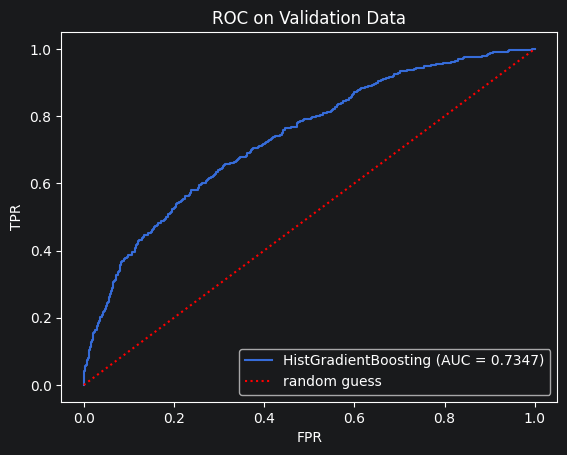

In [240]:
val_scores = model.predict_proba(X_val)[:, 1]
val_predictions = model.predict(X_val)
val_auc = roc_auc_score(y_val, val_scores)

print('Evaluation on the validation set:')
print('Kaggle scored this problem on AUC, which is why we selected it here.\n')
test_scores = model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_scores)

print(f'Validation AUC: {val_auc:.4f}')
print(f'Test AUC: {test_auc:.4f}')
print('Very close AUC, I don\' think it\'s overfitting.')

fpr, tpr, thresholds = roc_curve(y_val, val_scores)

plt.plot(fpr, tpr, label=f'HistGradientBoosting (AUC = {val_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='dotted', color='red', label='random guess')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC on Validation Data')
plt.legend()
plt.show()